### SDSS Galaxies (GALs) vs Quasars (QSOs)
We're now going to classify galaxies vs quasars in the Sloan Digital Sky Survey.
This is one of the most famous examples of machine-learning classification in astronomy.

**Tasks**
1. Create arrays for the colors. Also create an array with the class labels where galaxy=0 and quasar=1.
2. Classify the dataset against the target label.
Try some of the classification methods seen so far and evaluate the performance using the ROC curve.

**Questions**
1. Try using different colors (a subset of them first, than all together). Which is the most important feature?
2. What are the colors that better satisfy or invalidate the "Naive" assumption of independence between the attributes?

In [1]:
import numpy as np
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_predict, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, precision_recall_curve

import pandas as pd

#### Qualitative analysis of the dataset

In [2]:
table_gal_qso = pd.read_csv("data_files/galaxyquasar.csv")

In [3]:
table_gal_qso.sample(10, random_state=42)

,u,g,r,i,z,class,z1,zerr
33553,19.57831,18.40447,17.63287,17.25110,16.95246,GALAXY,0.166232,0.000016
9427,19.06137,17.50107,16.83883,16.45573,16.16996,GALAXY,0.022549,0.000018
199,19.14627,18.85902,18.63394,18.45354,18.45074,QSO,1.959382,0.000621
12447,18.93706,17.70914,17.15452,16.82830,16.58504,GALAXY,0.039513,0.000009
39489,19.48735,17.97041,17.30248,16.96168,16.70040,GALAXY,0.027510,0.000026
42724,19.12623,17.86076,17.24661,16.83935,16.61520,GALAXY,0.070593,0.000007
10822,19.39851,18.12560,17.46205,17.07351,16.80993,GALAXY,0.116643,0.000013
49498,18.95000,17.92924,17.34004,16.95222,16.75507,GALAXY,0.116560,0.000007
4144,18.69158,18.62085,18.57032,18.34672,18.27023,QSO,1.870589,0.000225
36958,18.81931,17.89250,17.58472,17.44312,17.32130,GALAXY,0.016083,0.000005


In [4]:
# Assign unique integers from 0 to 1 to each object type (GAL or QSO)
le = LabelEncoder()
table_gal_qso['class'] = le.fit_transform(table_gal_qso['class'])
labels = le.inverse_transform(table_gal_qso['class'])
class_names = le.classes_
print(class_names)

['GALAXY' 'QSO']


In [5]:
table_gal_qso.sample(10, random_state=42)

,u,g,r,i,z,class,z1,zerr
33553,19.57831,18.40447,17.63287,17.25110,16.95246,0,0.166232,0.000016
9427,19.06137,17.50107,16.83883,16.45573,16.16996,0,0.022549,0.000018
199,19.14627,18.85902,18.63394,18.45354,18.45074,1,1.959382,0.000621
12447,18.93706,17.70914,17.15452,16.82830,16.58504,0,0.039513,0.000009
39489,19.48735,17.97041,17.30248,16.96168,16.70040,0,0.027510,0.000026
42724,19.12623,17.86076,17.24661,16.83935,16.61520,0,0.070593,0.000007
10822,19.39851,18.12560,17.46205,17.07351,16.80993,0,0.116643,0.000013
49498,18.95000,17.92924,17.34004,16.95222,16.75507,0,0.116560,0.000007
4144,18.69158,18.62085,18.57032,18.34672,18.27023,1,1.870589,0.000225
36958,18.81931,17.89250,17.58472,17.44312,17.32130,0,0.016083,0.000005


In [6]:
table_gal_qso.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   u       50000 non-null  float64
 1   g       50000 non-null  float64
 2   r       50000 non-null  float64
 3   i       50000 non-null  float64
 4   z       50000 non-null  float64
 5   class   50000 non-null  int64  
 6   z1      50000 non-null  float64
 7   zerr    50000 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 3.1 MB


In [7]:
# remember sklearn requires format (n_samples, n_features)
x1 = np.array(table_gal_qso["u"])-np.array(table_gal_qso["g"])
x2 = np.array(table_gal_qso["g"])-np.array(table_gal_qso["r"])
x3 = np.array(table_gal_qso["r"])-np.array(table_gal_qso["i"])
x4 = np.array(table_gal_qso["i"])-np.array(table_gal_qso["z"])
y = np.array(table_gal_qso["class"])
X_1c = np.array([x1]).T
X_2c = np.array([x1, x2]).T
X_3c = np.array([x1, x2, x3]).T
X_4c = np.array([x1, x2, x3, x4]).T

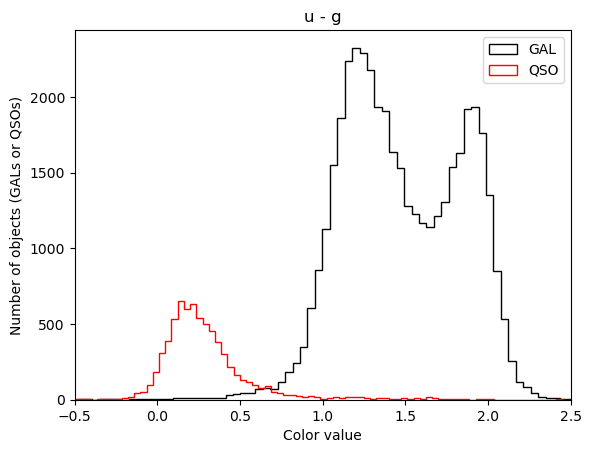

In [8]:
plt.hist(x1[y==0], bins=150, histtype='step', color='black', label="GAL")
plt.hist(x1[y==1], bins=150, histtype='step', color='red', label="QSO")
plt.title("u - g")
plt.ylabel("Number of objects (GALs or QSOs)")
plt.xlabel("Color value")
plt.legend(loc="upper right")
plt.xlim(-0.5, 2.5)
plt.show()
plt.close()

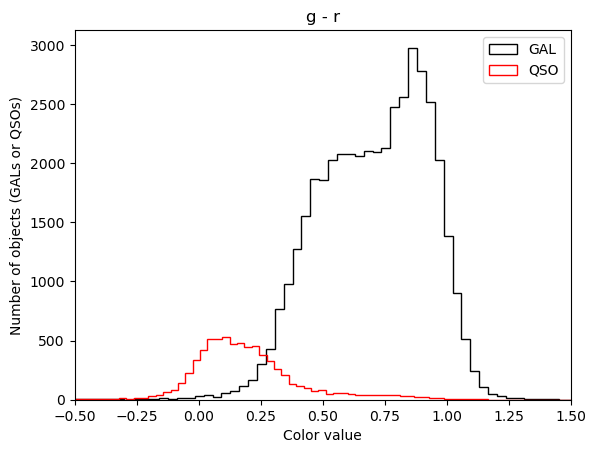

In [9]:
plt.hist(x2[y==0], bins=400, histtype='step', color='black', label="GAL")
plt.hist(x2[y==1], bins=400, histtype='step', color='red', label="QSO")
plt.title("g - r")
plt.ylabel("Number of objects (GALs or QSOs)")
plt.xlabel("Color value")
plt.legend(loc="upper right")
plt.xlim(-0.5, 1.5)
plt.show()
plt.close()

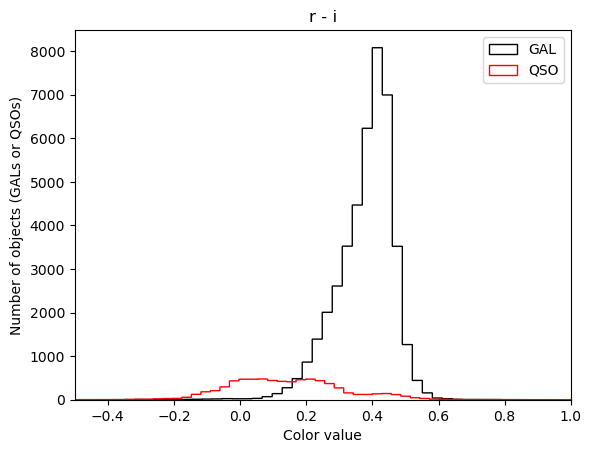

In [10]:
plt.hist(x3[y==0], bins=700, histtype='step', color='black', label="GAL")
plt.hist(x3[y==1], bins=700, histtype='step', color='red', label="QSO")
plt.title("r - i")
plt.ylabel("Number of objects (GALs or QSOs)")
plt.xlabel("Color value")
plt.legend(loc="upper right")
plt.xlim(-0.5, 1.0)
plt.show()
plt.close()

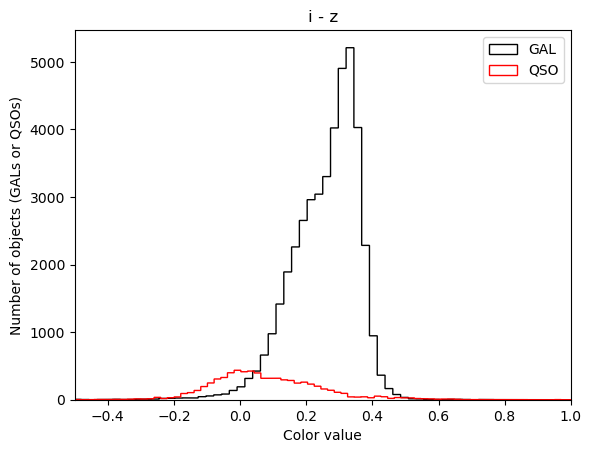

In [11]:
plt.hist(x4[y==0], bins=1000, histtype='step', color='black', label="GAL")
plt.hist(x4[y==1], bins=1000, histtype='step', color='red', label="QSO")
plt.title("i - z")
plt.ylabel("Number of objects (GALs or QSOs)")
plt.xlabel("Color value")
plt.legend(loc="upper right")
plt.xlim(-0.5, 1.0)
plt.show()
plt.close()

We can notice that the classes are more saparated using the "u-g" color.

#### Only u-g color feature with the K-Nearest Neighbor classifier

In [12]:
# Split the dataset in tranining + test dataset
X_CV, X_test, y_CV, y_test, CV_idx, test_idx = train_test_split(X_1c, y, range(len(X_1c)), test_size=0.15, random_state=42)

# Use cross validation to tune hyperparameters such as the number of neighbors K
scores = []
Kvals = np.arange(1, 20)
for K in Kvals:
    clf = KNeighborsClassifier(n_neighbors=K)
    CVpredK = cross_val_predict(clf, X_CV, y_CV)
    scores.append(f1_score(y_CV, CVpredK)) # do not use accuracy since classes are unbalanced (QSOs are rare)

tuned_K = Kvals[np.argmax(scores)]
# Final KNeighborsClassifier fit with tuned hyperparameter K
knc = KNeighborsClassifier(tuned_K)
knc.fit(X_CV, y_CV)
# Predict KNeighborsClassifier on test dataset
y_pred_knc = knc.predict(X_test)
# For performance you need the probabilities (e.g. of class 1), not the class predictions themselves
y_prob_knc = knc.predict_proba(X_test)[:, 1]

print("accuracy knc: {:.3f}".format(accuracy_score(y_test, y_pred_knc)))
print("precision knc: {:.3f}".format(precision_score(y_test, y_pred_knc)))
print("recall knc: {:.3f}".format(recall_score(y_test, y_pred_knc)))
print("f1 knc: {:.3f}".format(f1_score(y_test, y_pred_knc)))

accuracy knc: 0.980
precision knc: 0.936
recall knc: 0.918
f1 knc: 0.927


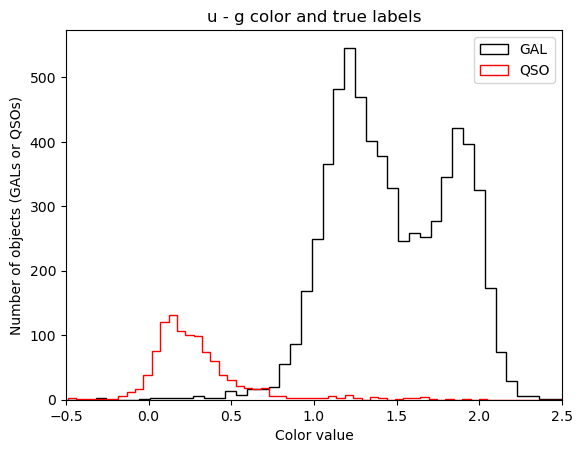

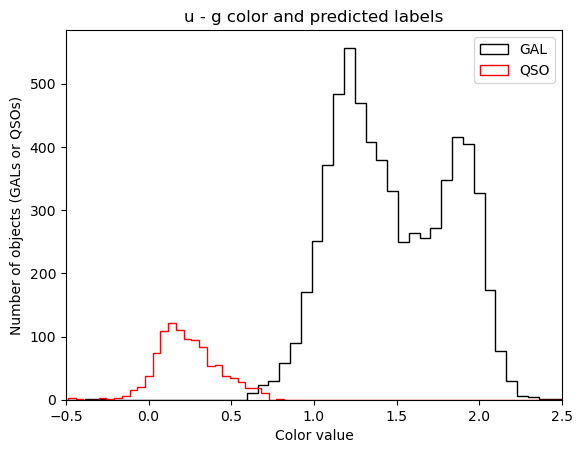

In [13]:
plt.hist(X_test.flatten()[y_test==0], bins="auto", histtype='step', color='black', label="GAL")
plt.hist(X_test.flatten()[y_test==1], bins="auto", histtype='step', color='red', label="QSO")
plt.title("u - g color and true labels")
plt.ylabel("Number of objects (GALs or QSOs)")
plt.xlabel("Color value")
plt.legend(loc="upper right")
plt.xlim(-0.5, 2.5)
plt.show()
plt.close()

plt.hist(X_test.flatten()[y_pred_knc==0], bins="auto", histtype='step', color='black', label="GAL")
plt.hist(X_test.flatten()[y_pred_knc==1], bins="auto", histtype='step', color='red', label="QSO")
plt.title("u - g color and predicted labels")
plt.ylabel("Number of objects (GALs or QSOs)")
plt.xlabel("Color value")
plt.legend(loc="upper right")
plt.xlim(-0.5, 2.5)
plt.show()
plt.close()

#### Different combinations of color features with the Gaussian Naive Bayes classifier

In [14]:
# Split the dataset in tranining + test dataset
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(X_4c, y, range(len(X_4c)), test_size=0.25, random_state=42)

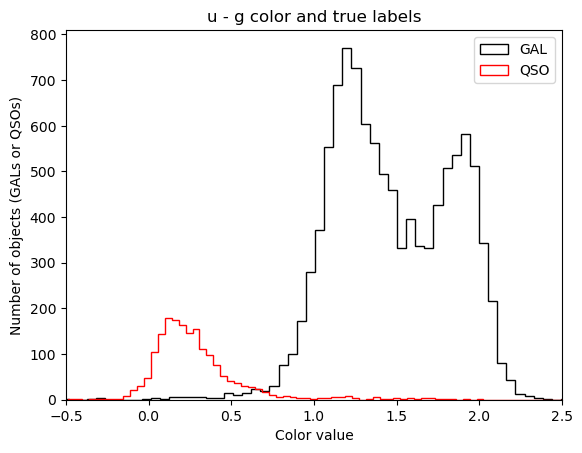

In [15]:
x_plot = x1[test_idx]
plt.hist(x_plot[y_test==0], bins="auto", density=False, histtype='step', color='black', label="GAL")
plt.hist(x_plot[y_test==1], bins="auto", density=False, histtype='step', color='red', label="QSO")
plt.title("u - g color and true labels")
plt.legend(loc="upper right")
plt.ylabel("Number of objects (GALs or QSOs)")
plt.xlabel("Color value")
plt.xlim(-0.5, 2.5)
plt.show()
plt.close()

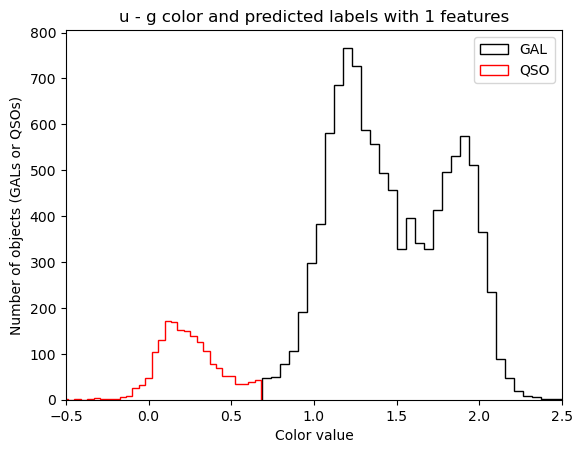

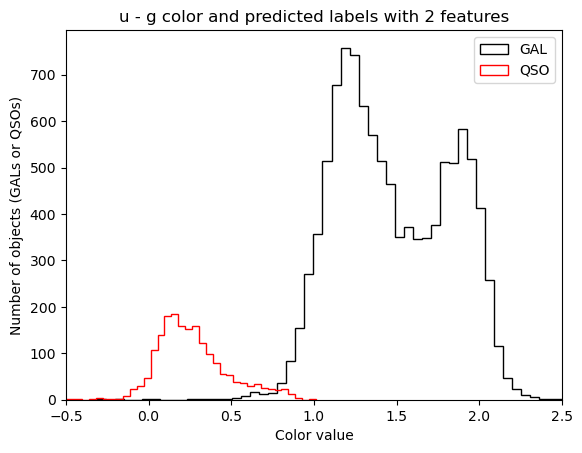

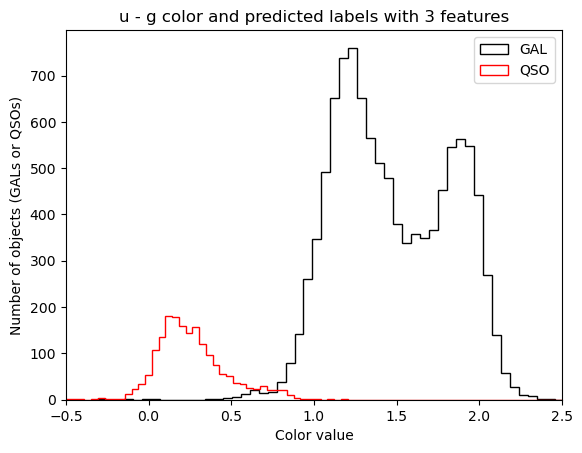

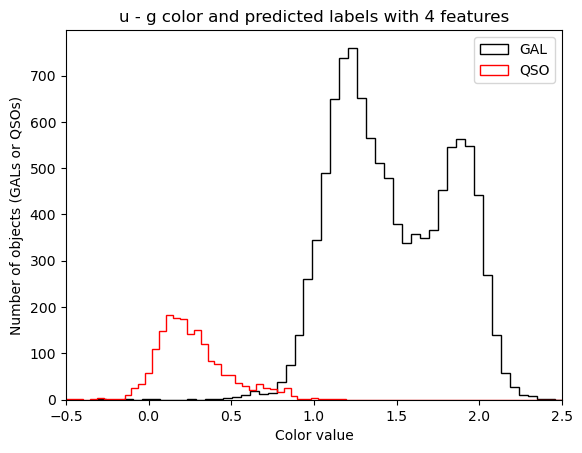

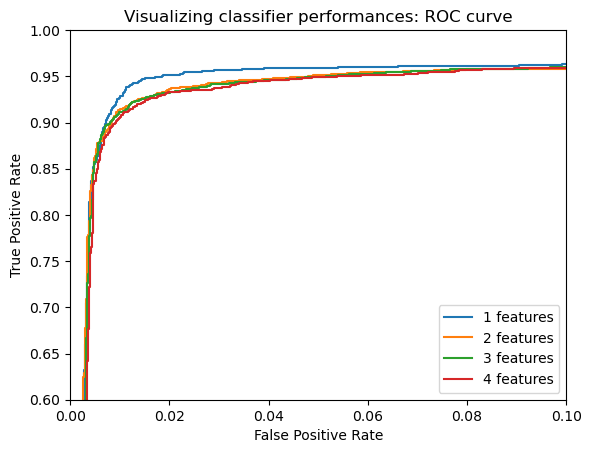

In [16]:
for i in range(4):
  gnb = GaussianNB()
  gnb.fit(X_train[:, 0:i+1], y_train)
  y_pred_gnb = gnb.predict(X_test[:, 0:i+1])

  plt.hist(x_plot[y_pred_gnb==0], bins="auto", density=False, histtype='step', color='black', label="GAL")
  plt.hist(x_plot[y_pred_gnb==1], bins="auto", density=False, histtype='step', color='red', label="QSO")
  plt.title("u - g color and predicted labels with {:.0f} features".format(i+1))
  plt.legend(loc="upper right")
  plt.ylabel("Number of objects (GALs or QSOs)")
  plt.xlabel("Color value")
  plt.xlim(-0.5, 2.5)
  plt.show()
  plt.close()

for i in range(4):
  gnb = GaussianNB()
  gnb.fit(X_train[:, 0:i+1], y_train)
  y_prob_gnb = gnb.predict_proba(X_test[:, 0:i+1])[:, 1]

  fpr_gnb, tpr_gnb, thresh1_gnb = roc_curve(y_test, y_prob_gnb)
  plt.plot(fpr_gnb, tpr_gnb, label=str(i+1)+" features")

plt.title("Visualizing classifier performances: ROC curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.xlim(0, 0.1)
plt.ylim(0.6, 1)
plt.legend()
plt.show()

#### All features

In [17]:
# Split the dataset in tranining + test dataset
X_CV, X_test, y_CV, y_test, CV_idx, test_idx = train_test_split(X_4c, y, range(len(X_4c)), test_size=0.15, random_state=42)

In [18]:
print(X_CV.shape)
print(X_test.shape)

(42500, 4)
(7500, 4)


**K-Nearest Neighbor (KNN) classifier**

In [19]:
# Use cross validation to tune hyperparameters such as the number of neighbors K
scores = []
Kvals = np.arange(1, 20)
for K in Kvals:
    clf = KNeighborsClassifier(n_neighbors=K)
    CVpredK = cross_val_predict(clf, X_CV, y_CV)
    scores.append(f1_score(y_CV, CVpredK)) # do not use accuracy since classes are unbalanced (QSOs are rare)

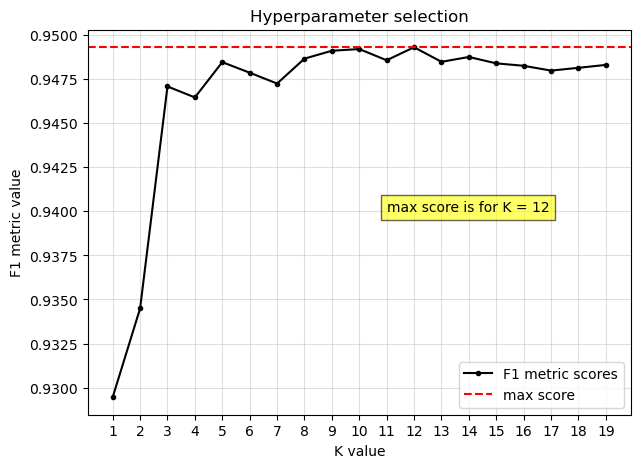

In [20]:
# Plot number of neighbors vs score
fig = plt.figure(figsize=(7, 5))
plt.plot(Kvals, scores, ".-k", label="F1 metric scores")
plt.xticks(Kvals)
plt.xlabel('K value')
plt.ylabel('F1 metric value')
plt.title('Hyperparameter selection')
plt.text(11, 0.94, "max score is for K = {:d}".format(Kvals[np.argmax(scores)]),
         bbox=dict(facecolor='yellow', alpha=0.6, edgecolor='black'))
plt.axhline(y=scores[np.argmax(scores)], color='r', linestyle='--', label="max score")
plt.legend()
plt.grid(alpha=0.4)
plt.show()

In [21]:
tuned_K = Kvals[np.argmax(scores)]
# Final KNeighborsClassifier fit with tuned hyperparameter K
knc = KNeighborsClassifier(tuned_K)
knc.fit(X_CV, y_CV)
# Predict KNeighborsClassifier on test dataset
y_pred_knc = knc.predict(X_test)
# For performance you need the probabilities (e.g. of class 1), not the class predictions themselves
y_prob_knc = knc.predict_proba(X_test)[:, 1]

In [22]:
print("accuracy knc: {:.3f}".format(accuracy_score(y_test, y_pred_knc)))
print("precision knc: {:.3f}".format(precision_score(y_test, y_pred_knc)))
print("recall knc: {:.3f}".format(recall_score(y_test, y_pred_knc)))

accuracy knc: 0.986
precision knc: 0.962
recall knc: 0.934


**Gaussian Naive Bayes (GNB) classifier**

In [23]:
gnb = GaussianNB()
gnb.fit(X_CV, y_CV)
y_pred_gnb = gnb.predict(X_test)
y_prob_gnb = gnb.predict_proba(X_test)[:, 1]

In [24]:
print("accuracy gnb: {:.3f}".format(accuracy_score(y_test, y_pred_gnb)))
print("precision gnb: {:.3f}".format(precision_score(y_test, y_pred_gnb)))
print("recall gnb: {:.3f}".format(recall_score(y_test, y_pred_gnb)))

accuracy gnb: 0.975
precision gnb: 0.895
recall gnb: 0.928


**Linear Discriminant Analysis (LDA) classifier**

In [25]:
lda = LDA()
lda.fit(X_CV, y_CV)
y_pred_lda = lda.predict(X_test)
y_prob_lda = lda.predict_proba(X_test)[:, 1]

In [26]:
print("accuracy lda: {:.3f}".format(accuracy_score(y_test, y_pred_lda)))
print("precision lda: {:.3f}".format(precision_score(y_test, y_pred_lda)))
print("recall lda: {:.3f}".format(recall_score(y_test, y_pred_lda)))

accuracy lda: 0.981
precision lda: 0.936
recall lda: 0.925


**Quadratic Discriminant Analysis (QDA) classifier**

In [27]:
qda = QDA()
qda.fit(X_CV, y_CV)
y_pred_qda = qda.predict(X_test)
y_prob_qda = qda.predict_proba(X_test)[:, 1]

In [28]:
print("accuracy qda: {:.3f}".format(accuracy_score(y_test, y_pred_qda)))
print("precision qda: {:.3f}".format(precision_score(y_test, y_pred_qda)))
print("recall qda: {:.3f}".format(recall_score(y_test, y_pred_qda)))

accuracy qda: 0.980
precision qda: 0.933
recall qda: 0.924


Metric:        | Measures:                    | Focuses On:             | Useful When:
---------------|------------------------------|-------------------------|-----------------------------------------
Accuracy       | Overall correctness          | All classes             | Classes are balanced
Precision      | Correctness of positives     | False positives         | False positives are costly
Recall         | Coverage of actual positives | False negatives         | False negatives are costly


##### Plotting performances

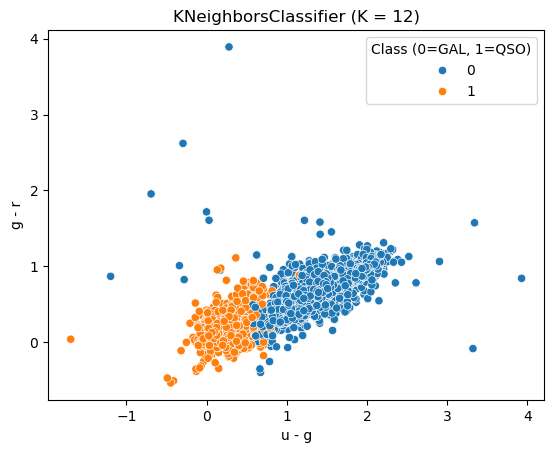

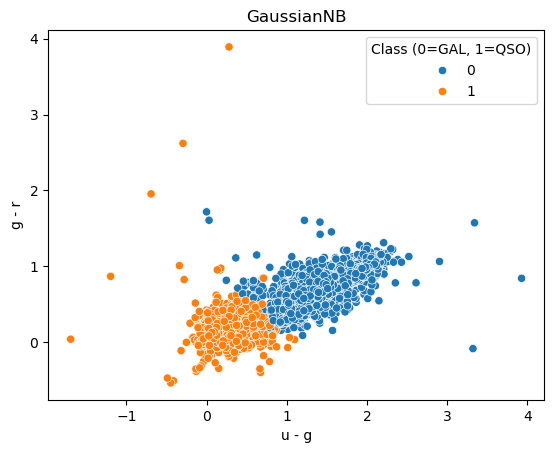

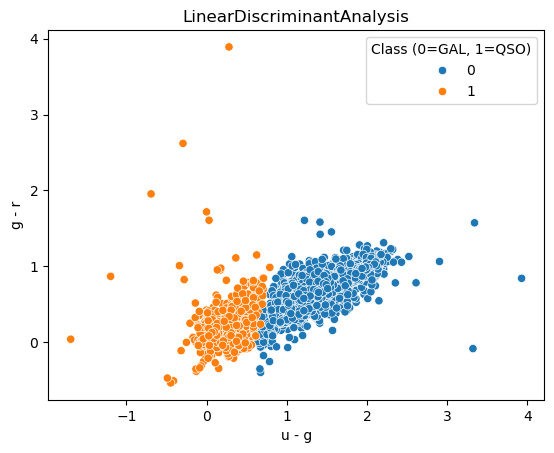

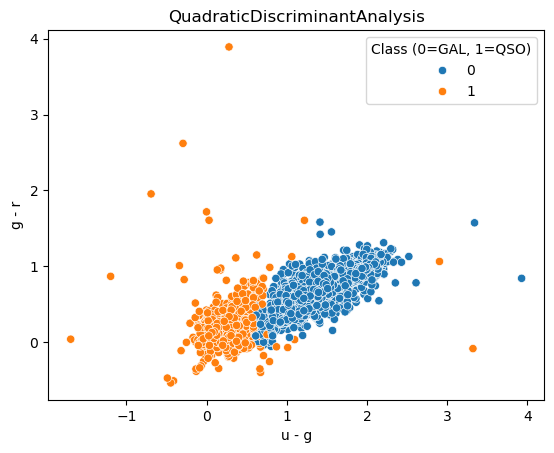

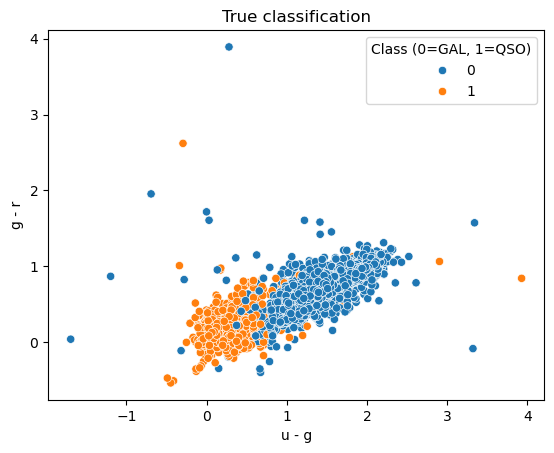

In [29]:
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_pred_knc)
plt.legend(title="Class (0=GAL, 1=QSO)")
plt.title("KNeighborsClassifier (K = 12)")
plt.xlabel("u - g")
plt.ylabel("g - r")
plt.show()
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_pred_gnb)
plt.legend(title="Class (0=GAL, 1=QSO)")
plt.title("GaussianNB")
plt.xlabel("u - g")
plt.ylabel("g - r")
plt.show()
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_pred_lda)
plt.legend(title="Class (0=GAL, 1=QSO)")
plt.title("LinearDiscriminantAnalysis")
plt.xlabel("u - g")
plt.ylabel("g - r")
plt.show()
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_pred_qda)
plt.legend(title="Class (0=GAL, 1=QSO)")
plt.title("QuadraticDiscriminantAnalysis")
plt.xlabel("u - g")
plt.ylabel("g - r")
plt.show()
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_test)
plt.legend(title="Class (0=GAL, 1=QSO)")
plt.title("True classification")
plt.xlabel("u - g")
plt.ylabel("g - r")
plt.show()

In [30]:
fpr_knc, tpr_knc, thresh1_knc = roc_curve(y_test, y_prob_knc)
precision_knc, recall_knc, thresh2_knc = precision_recall_curve(y_test, y_prob_knc)

fpr_gnb, tpr_gnb, thresh1_gnb = roc_curve(y_test, y_prob_gnb)
precision_gnb, recall_gnb, thresh2_gnb = precision_recall_curve(y_test, y_prob_gnb)

fpr_lda, tpr_lda, thresh1_lda = roc_curve(y_test, y_prob_lda)
precision_lda, recall_lda, thresh2_lda = precision_recall_curve(y_test, y_prob_lda)

fpr_qda, tpr_qda, thresh1_qda = roc_curve(y_test, y_prob_qda)
precision_qda, recall_qda, thresh2_qda = precision_recall_curve(y_test, y_prob_qda)

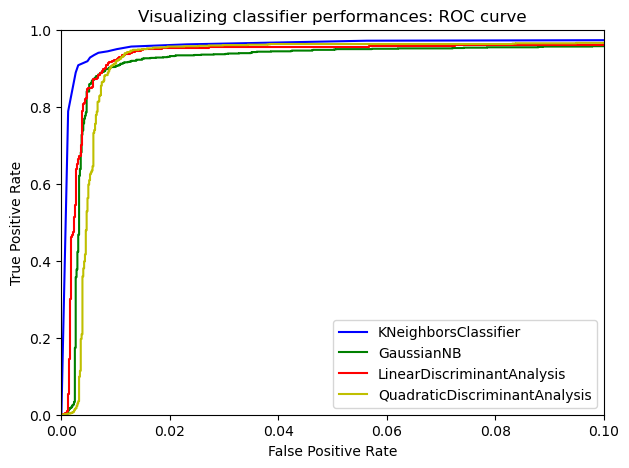

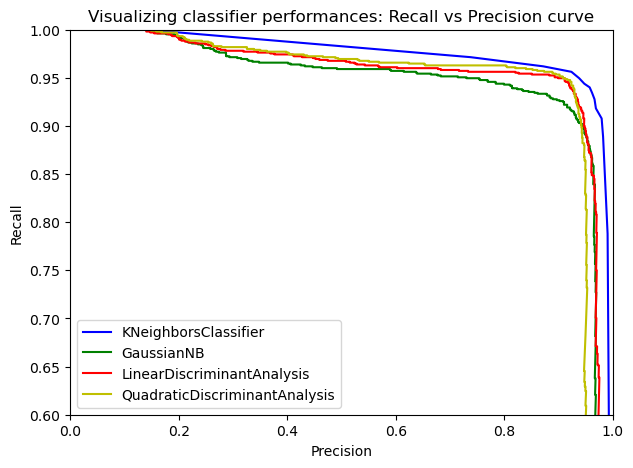

In [31]:
plt.figure(figsize=(7, 5))
plt.title("Visualizing classifier performances: ROC curve")
plt.plot(fpr_knc, tpr_knc, "b-", label="KNeighborsClassifier")
plt.plot(fpr_gnb, tpr_gnb, "g-", label="GaussianNB")
plt.plot(fpr_lda, tpr_lda, "r-", label="LinearDiscriminantAnalysis")
plt.plot(fpr_qda, tpr_qda, "y-", label="QuadraticDiscriminantAnalysis")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.xlim(0, 0.1)
plt.ylim(0, 1)
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.title("Visualizing classifier performances: Recall vs Precision curve")
plt.plot(precision_knc, recall_knc, "b-", label="KNeighborsClassifier")
plt.plot(precision_gnb, recall_gnb, "g-", label="GaussianNB")
plt.plot(precision_lda, recall_lda, "r-", label="LinearDiscriminantAnalysis")
plt.plot(precision_qda, recall_qda, "y-", label="QuadraticDiscriminantAnalysis")
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.xlim(0, 1)
plt.ylim(0.6, 1)
plt.legend()
plt.show()

In [32]:
thresh2_knc = np.insert(thresh2_knc, 0, 0.0)
thresh2_gnb = np.insert(thresh2_gnb, 0, 0.0)
thresh2_lda = np.insert(thresh2_lda, 0, 0.0)
thresh2_qda = np.insert(thresh2_qda, 0, 0.0)

KNeighborsClassifier
Precision at 90% : 0.924
Recall at 90% precision : 0.956
Threshold at 90% precision : 0.167


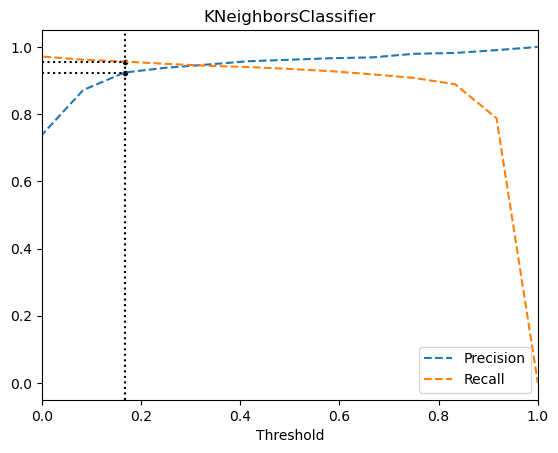

GaussianNB
Precision at 90% : 0.900
Recall at 90% precision : 0.927
Threshold at 90% precision : 0.547


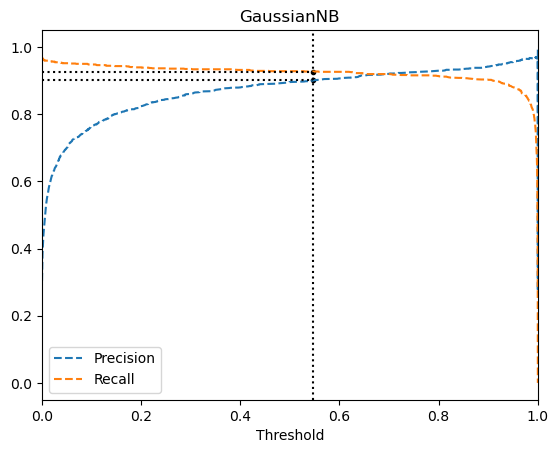

LinearDiscriminantAnalysis
Precision at 90% : 0.900
Recall at 90% precision : 0.950
Threshold at 90% precision : 0.241


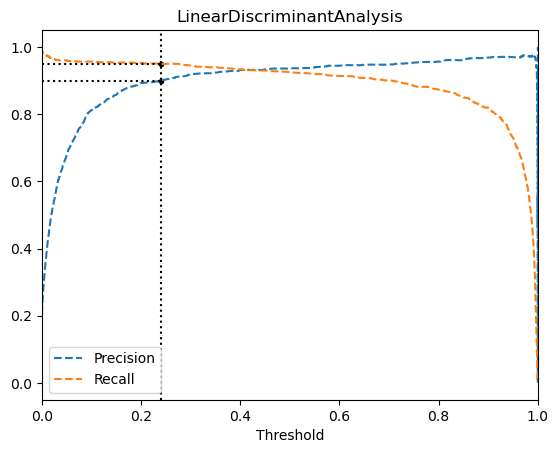

QuadraticDiscriminantAnalysis
Precision at 90% : 0.900
Recall at 90% precision : 0.953
Threshold at 90% precision : 0.172


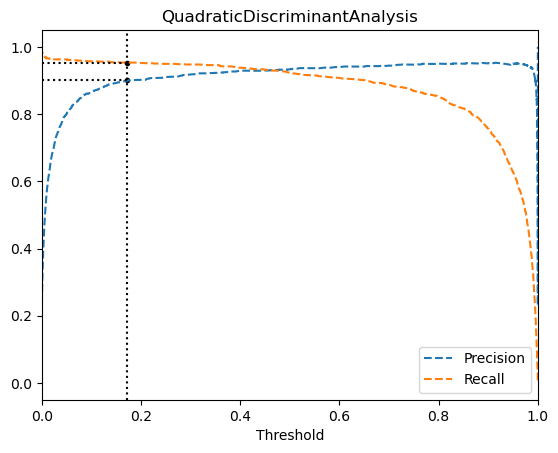

In [33]:
print("KNeighborsClassifier")
rec_90_prec = recall_knc[np.argmax(precision_knc >= 0.90)]
thresh_90_prec = thresh2_knc[np.argmax(precision_knc >= 0.90)]
prec_90_prec = precision_knc[np.argmax(precision_knc >= 0.90)]
print("Precision at 90% : {:.3f}".format(prec_90_prec))
print("Recall at 90% precision : {:.3f}".format(rec_90_prec))
print("Threshold at 90% precision : {:.3f}".format(thresh_90_prec))

plt.plot(thresh2_knc, precision_knc, "--", label="Precision")
plt.plot(thresh2_knc, recall_knc, "--", label="Recall")
plt.axhline(y=prec_90_prec, color='k', linestyle=':', xmin=0, xmax=thresh_90_prec)
plt.axhline(y=rec_90_prec, color='k', linestyle=':', xmin=0, xmax=thresh_90_prec)
plt.axvline(x=thresh_90_prec, color='k', linestyle=':')
plt.scatter(thresh_90_prec, prec_90_prec, color='k', marker=".")
plt.scatter(thresh_90_prec, rec_90_prec, color='k', marker=".")
plt.title("KNeighborsClassifier")
plt.xlabel("Threshold")
plt.xlim(0, 1)
plt.legend()
plt.show()
plt.close()

print("GaussianNB")
rec_90_prec = recall_gnb[np.argmax(precision_gnb >= 0.90)]
thresh_90_prec = thresh2_gnb[np.argmax(precision_gnb >= 0.90)]
prec_90_prec = precision_gnb[np.argmax(precision_gnb >= 0.90)]
print("Precision at 90% : {:.3f}".format(prec_90_prec))
print("Recall at 90% precision : {:.3f}".format(rec_90_prec))
print("Threshold at 90% precision : {:.3f}".format(thresh_90_prec))

plt.plot(thresh2_gnb, precision_gnb, "--", label="Precision")
plt.plot(thresh2_gnb, recall_gnb, "--", label="Recall")
plt.axhline(y=prec_90_prec, color='k', linestyle=':', xmin=0, xmax=thresh_90_prec)
plt.axhline(y=rec_90_prec, color='k', linestyle=':', xmin=0, xmax=thresh_90_prec)
plt.axvline(x=thresh_90_prec, color='k', linestyle=':')
plt.scatter(thresh_90_prec, prec_90_prec, color='k', marker=".")
plt.scatter(thresh_90_prec, rec_90_prec, color='k', marker=".")
plt.title("GaussianNB")
plt.xlabel("Threshold")
plt.xlim(0, 1)
plt.legend()
plt.show()
plt.close()

print("LinearDiscriminantAnalysis")
rec_90_prec = recall_lda[np.argmax(precision_lda >= 0.90)]
thresh_90_prec = thresh2_lda[np.argmax(precision_lda >= 0.90)]
prec_90_prec = precision_lda[np.argmax(precision_lda >= 0.90)]
print("Precision at 90% : {:.3f}".format(prec_90_prec))
print("Recall at 90% precision : {:.3f}".format(rec_90_prec))
print("Threshold at 90% precision : {:.3f}".format(thresh_90_prec))

plt.plot(thresh2_lda, precision_lda, "--", label="Precision")
plt.plot(thresh2_lda, recall_lda, "--", label="Recall")
plt.axhline(y=prec_90_prec, color='k', linestyle=':', xmin=0, xmax=thresh_90_prec)
plt.axhline(y=rec_90_prec, color='k', linestyle=':', xmin=0, xmax=thresh_90_prec)
plt.axvline(x=thresh_90_prec, color='k', linestyle=':')
plt.scatter(thresh_90_prec, prec_90_prec, color='k', marker=".")
plt.scatter(thresh_90_prec, rec_90_prec, color='k', marker=".")
plt.title("LinearDiscriminantAnalysis")
plt.xlabel("Threshold")
plt.xlim(0, 1)
plt.legend()
plt.show()
plt.close()

print("QuadraticDiscriminantAnalysis")
rec_90_prec = recall_qda[np.argmax(precision_qda >= 0.90)]
thresh_90_prec = thresh2_qda[np.argmax(precision_qda >= 0.90)]
prec_90_prec = precision_qda[np.argmax(precision_qda >= 0.90)]
print("Precision at 90% : {:.3f}".format(prec_90_prec))
print("Recall at 90% precision : {:.3f}".format(rec_90_prec))
print("Threshold at 90% precision : {:.3f}".format(thresh_90_prec))

plt.plot(thresh2_qda, precision_qda, "--", label="Precision")
plt.plot(thresh2_qda, recall_qda, "--", label="Recall")
plt.axhline(y=prec_90_prec, color='k', linestyle=':', xmin=0, xmax=thresh_90_prec)
plt.axhline(y=rec_90_prec, color='k', linestyle=':', xmin=0, xmax=thresh_90_prec)
plt.axvline(x=thresh_90_prec, color='k', linestyle=':')
plt.scatter(thresh_90_prec, prec_90_prec, color='k', marker=".")
plt.scatter(thresh_90_prec, rec_90_prec, color='k', marker=".")
plt.title("QuadraticDiscriminantAnalysis")
plt.xlabel("Threshold")
plt.xlim(0, 1)
plt.legend()
plt.show()
plt.close()